# check the distribution of train, test, and validation set

           dataset\feminine\o0480064013326435745.png
0  dataset\natural\49bb7ea87028c97078b3b47d7e8a82...
1  dataset\street\b0d569dafa564444e343ef2c81f50f8...
2  dataset\rock\band-t-shirt-hipster-girl-outfit-...
3  dataset\rock\80s-glam-rock-fashion-trend-fall-...
4                  dataset\dressy\14100658829571.jpg


,train,val,test
label,,,
conservative,643,138,137
dressy,629,135,134
ethnic,601,129,129
fairy,668,143,144
feminine,563,121,121
gal,668,142,143
girlish,773,166,166
kireime-casual,738,158,158
lolita,744,159,160


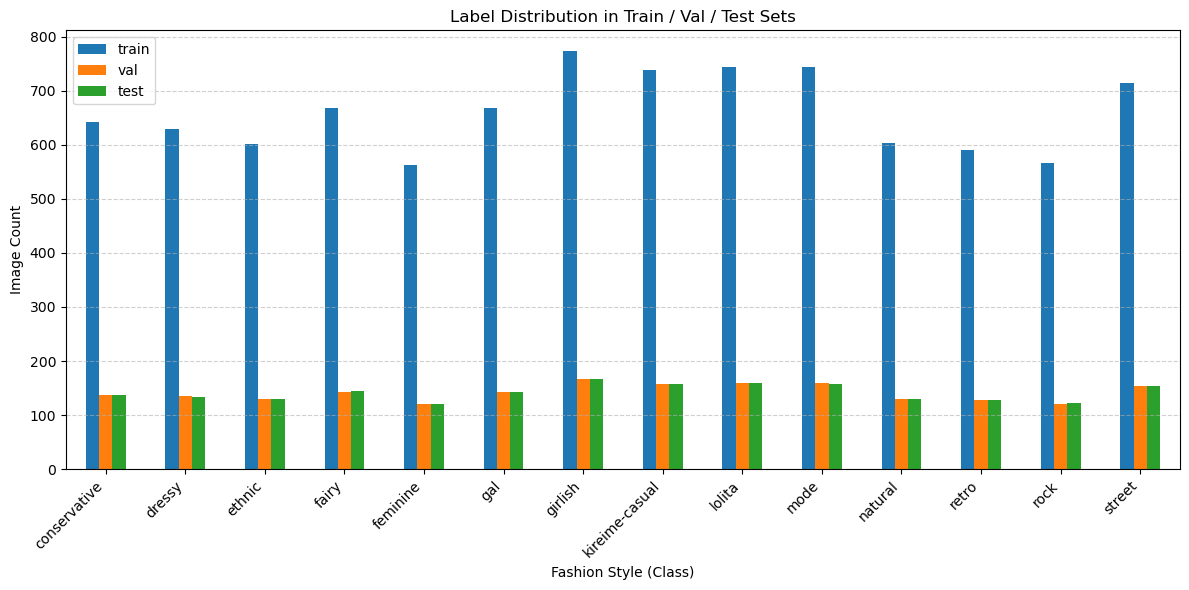

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the fixed CSVs
train_df = pd.read_csv("train_new.csv")
val_df   = pd.read_csv("val_new.csv")
test_df  = pd.read_csv("test_new.csv")

# Show the first few lines to confirm column names
print(train_df.head())

# ----- Adjust if your column names differ -----
# If CSVs have only 1 column (path), and the class is part of the path like:
# dataset/kireime-casual/filename.jpg
# then extract the class from the path:

def extract_label(path):
    # split by "/" and take the second component (after "dataset")
    return path.split("\\")[1]

train_df["label"] = train_df.iloc[:,0].apply(extract_label)
val_df["label"]   = val_df.iloc[:,0].apply(extract_label)
test_df["label"]  = test_df.iloc[:,0].apply(extract_label)

# Count label frequencies
train_counts = train_df["label"].value_counts().sort_index()
val_counts   = val_df["label"].value_counts().sort_index()
test_counts  = test_df["label"].value_counts().sort_index()

# Combine into one DataFrame for plotting
dist_df = pd.DataFrame({
    "train": train_counts,
    "val": val_counts,
    "test": test_counts
}).fillna(0).astype(int)

display(dist_df)

# ----- Plot -----
dist_df.plot(kind="bar", figsize=(12,6))
plt.title("Label Distribution in Train / Val / Test Sets")
plt.xlabel("Fashion Style (Class)")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Setup: Experiment name & config

In [11]:
# EXPT NAME (appears in saved files / logs)
EXPT_NAME = "resnet50_fashionstyle14_baseline"

TRAIN_CSV = "train_new.csv"
VAL_CSV   = "val_new.csv"
TEST_CSV  = "test_new.csv"

# Data
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  # set higher if your runtime supports it

# Training
EPOCHS = 25
LR = 1e-4 # 3e-4
WEIGHT_DECAY = 2e-4 # 1e-4
PATIENCE = 5  # early stopping on val macro-F1
SEED = 42

# Number of classes (FashionStyle14)
NUM_CLASSES = 14

# Where to save artifacts
OUT_DIR = f"./outputs_{EXPT_NAME}"

# Imports, seeding, and helpers

In [12]:
import os, random, math, json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from tqdm.auto import tqdm

# Reproducibility
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Load CSVs and build label mapping

In [13]:
# Each CSV has a single column with POSIX paths like:
# dataset/kireime-casual/レディース.....jpg
# We DO NOT modify the filename text.

def read_paths(csv_path):
    # Handles both header/no-header cases
    df = pd.read_csv(csv_path, header=None, encoding="utf-8")
    # If the first row looks like a header (contains 'path'), handle that
    if df.shape[1] == 1:
        df.columns = ["path"]
    else:
        # If there are extra columns, keep the first as path
        df = df.iloc[:, [0]]
        df.columns = ["path"]
    return df

train_df = read_paths(TRAIN_CSV)
val_df   = read_paths(VAL_CSV)
test_df  = read_paths(TEST_CSV)

# Extract label as the folder right after "dataset/"
def extract_label(p):
    parts = str(p).split("\\")
    # Expect ["dataset", "<style>", "filename"]
    # If paths are deeper, take the second component as style
    return parts[1] if len(parts) > 1 else "unknown"

train_df["label"] = train_df["path"].apply(extract_label)
val_df["label"]   = val_df["path"].apply(extract_label)
test_df["label"]  = test_df["path"].apply(extract_label)

# Build label -> id mapping from TRAIN set (sorted for stability)
labels_sorted = sorted(train_df["label"].unique())
assert len(labels_sorted) == NUM_CLASSES, f"Expected {NUM_CLASSES} classes, got {len(labels_sorted)}"
label_to_id = {lbl: i for i, lbl in enumerate(labels_sorted)}
id_to_label = {i: lbl for lbl, i in label_to_id.items()}

# Attach numeric targets
train_df["target"] = train_df["label"].map(label_to_id)
val_df["target"]   = val_df["label"].map(label_to_id)
test_df["target"]  = test_df["label"].map(label_to_id)

print("Classes:", labels_sorted)
print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))
train_df.head()

Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Train/Val/Test sizes: 9199 1969 1980


,path,label,target
0,dataset\feminine\o0480064013326435745.png,feminine,4
1,dataset\natural\49bb7ea87028c97078b3b47d7e8a82...,natural,10
2,dataset\street\b0d569dafa564444e343ef2c81f50f8...,street,13
3,dataset\rock\band-t-shirt-hipster-girl-outfit-...,rock,12
4,dataset\dressy\14100658829571.jpg,dressy,1


# Transforms & Dataset definition

In [14]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),  # 256 for 224
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CsvImageDataset(Dataset):
    def __init__(self, df, transforms=None, root="."):
        self.paths = df["path"].tolist()
        self.targets = df["target"].tolist()
        self.transforms = transforms
        self.root = root

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        rel_path = self.paths[idx]
        # Keep filename exactly as-is (incl. %.. encodings and Unicode)
        img_path = os.path.join(self.root, rel_path)
        with Image.open(img_path) as im:
            im = im.convert("RGB")
        if self.transforms:
            im = self.transforms(im)
        target = self.targets[idx]
        return im, target, rel_path  # return path for debugging

DATA_ROOT = "FashionStyle14_v1\FashionStyle14_v1"  # note: parent of 'dataset'
train_ds = CsvImageDataset(train_df, transforms=train_tfms, root=DATA_ROOT)
val_ds   = CsvImageDataset(val_df,   transforms=eval_tfms, root=DATA_ROOT)
test_ds  = CsvImageDataset(test_df,  transforms=eval_tfms, root=DATA_ROOT)

# Dataloaders & (optional) class weights

In [15]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

# Optional class weighting to help minor imbalance
class_counts = train_df["target"].value_counts().sort_index().values
class_weights = (class_counts.sum() / (NUM_CLASSES * class_counts))
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Class counts:", class_counts)
print("Class weights:", class_weights.cpu().numpy())

Class counts: [643 628 597 665 564 665 768 732 743 732 603 590 564 705]
Class weights: [1.0218841  1.0462921  1.1006222  0.98807734 1.1650202  0.98807734
 0.85556173 0.89763856 0.88434917 0.89763856 1.0896707  1.1136804
 1.1650202  0.9320162 ]


# Build ResNet50 (pretrained) and training utilities

In [16]:
# Model
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

# Loss (CrossEntropy with optional weights)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(model, loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    all_preds, all_tgts = [], []
    running_loss = 0.0

    for imgs, tgts, _ in tqdm(loader, leave=False):
        imgs = imgs.to(device, non_blocking=True)
        tgts = tgts.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss = criterion(logits, tgts)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_tgts.append(tgts.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_tgts  = np.concatenate(all_tgts)

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_tgts, all_preds)
    macro_f1 = f1_score(all_tgts, all_preds, average="macro")
    return epoch_loss, acc, macro_f1

# Train loop with early stopping (by val Macro-F1)

In [47]:
best_f1 = -1.0
best_path = os.path.join(OUT_DIR, f"{EXPT_NAME}_best.pt")
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, train=False)
    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
        "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1,
        "lr": scheduler.get_last_lr()[0],
    })

    print(f"[{epoch:02d}] "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} f1={train_f1:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f}")

    # Early stopping on val macro-F1
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({"model_state": model.state_dict(),
                    "label_to_id": label_to_id,
                    "id_to_label": id_to_label,
                    "config": {
                        "IMG_SIZE": IMG_SIZE, "BATCH_SIZE": BATCH_SIZE,
                        "LR": LR, "WEIGHT_DECAY": WEIGHT_DECAY,
                        "EPOCHS": EPOCHS
                    }},
                   best_path)
        stop_counter = 0
    else:
        stop_counter += 1
        if stop_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best val F1 = {best_f1:.4f}")
            break

# Save training history
with open(os.path.join(OUT_DIR, f"{EXPT_NAME}_history.json"), "w") as f:
    json.dump(history, f, indent=2)
print("Best checkpoint:", best_path)

[01] train_loss=1.3367 acc=0.5765 f1=0.5712 | val_loss=0.8865 acc=0.6917 f1=0.6862


[02] train_loss=0.5789 acc=0.8018 f1=0.8020 | val_loss=0.8851 acc=0.7014 f1=0.6963


[03] train_loss=0.3617 acc=0.8791 f1=0.8797 | val_loss=0.9216 acc=0.7136 f1=0.7128


[04] train_loss=0.2235 acc=0.9248 f1=0.9255 | val_loss=0.9033 acc=0.7156 f1=0.7145


[05] train_loss=0.1685 acc=0.9450 f1=0.9455 | val_loss=0.8951 acc=0.7364 f1=0.7359


...

[12] train_loss=0.0334 acc=0.9902 f1=0.9904 | val_loss=1.0390 acc=0.7395 f1=0.7394


[13] train_loss=0.0276 acc=0.9921 f1=0.9920 | val_loss=1.0864 acc=0.7369 f1=0.7351


[14] train_loss=0.0259 acc=0.9922 f1=0.9923 | val_loss=1.1162 acc=0.7354 f1=0.7321


[15] train_loss=0.0191 acc=0.9942 f1=0.9943 | val_loss=1.1188 acc=0.7334 f1=0.7336


[16] train_loss=0.0142 acc=0.9961 f1=0.9961 | val_loss=1.0944 acc=0.7440 f1=0.7394
Early stopping at epoch 16. Best val F1 = 0.7439
Best checkpoint: ./outputs_resnet50_fashionstyle14_baseline\resnet50_fashionstyle14_baseline_best.pt


# Accuracy and loss curve

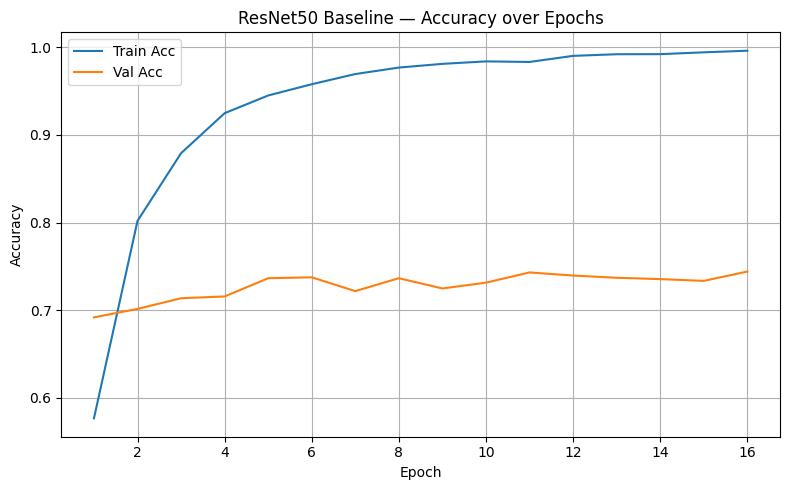

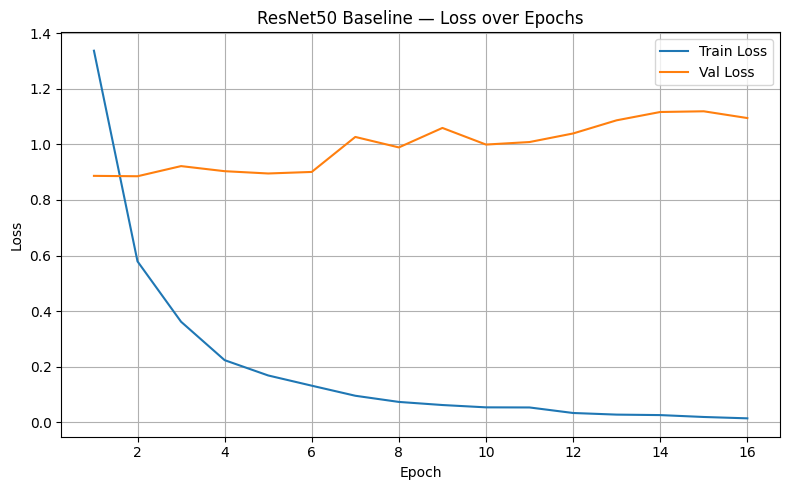

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import json

with open("outputs_resnet50_fashionstyle14_baseline\\resnet50_fashionstyle14_baseline_history.json", "r") as f:
    history = json.load(f)
df = pd.DataFrame(history)

# ---- Plot Accuracy ----
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_acc"], label="Train Acc")
plt.plot(df["epoch"], df["val_acc"], label="Val Acc")
plt.title("ResNet50 Baseline — Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Plot Loss ----
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
plt.title("ResNet50 Baseline — Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Load best model & evaluate on TEST set

In [17]:
best_path = os.path.join(OUT_DIR, f"{EXPT_NAME}_best.pt")

ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

# 2) Save per-image predictions to CSV
def save_predictions(model, loader, split_name, out_dir=OUT_DIR):
    model.eval()
    rows = []
    with torch.inference_mode():
        for imgs, tgts, paths in tqdm(loader, desc=f"Predict {split_name}"):
            imgs = imgs.to(device, non_blocking=True)
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            tgts = tgts.numpy()
            for i in range(len(paths)):
                rec = {
                    "path": paths[i],
                    "true_id": int(tgts[i]),
                    "true_label": id_to_label[int(tgts[i])],
                    "pred_id": int(preds[i]),
                    "pred_label": id_to_label[int(preds[i])],
                    "confidence": float(probs[i, preds[i]]),
                }
                for cls_id in range(NUM_CLASSES):
                    rec[f"prob_{id_to_label[cls_id]}"] = float(probs[i, cls_id])
                rows.append(rec)
    df = pd.DataFrame(rows)
    os.makedirs(out_dir, exist_ok=True)
    out_csv = os.path.join(out_dir, f"{EXPT_NAME}_{split_name}_predictions.csv")
    df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    print(f"Saved {len(df)} rows to {out_csv}")
    return df

test_df_pred = save_predictions(model, test_loader, "test")

# 3) Compute metrics from the saved dataframe
y_true = test_df_pred["true_id"].to_numpy()
y_pred = test_df_pred["pred_id"].to_numpy()


acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)

print(f"TEST — Acc: {acc:.4f} | Macro-P: {prec:.4f} | Macro-R: {rec:.4f} | Macro-F1: {f1:.4f}\n")

print("Per-class report:")
print(classification_report(
    y_true, y_pred,
    target_names=[id_to_label[i] for i in range(NUM_CLASSES)],
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[id_to_label[i] for i in range(NUM_CLASSES)],
    columns=[id_to_label[i] for i in range(NUM_CLASSES)]
)
cm_df

C:\Users\Sandy\AppData\Local\Temp\ipykernel_17540\3218389077.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_path, map_location=device)
Predict te

Saved 1980 rows to ./outputs_resnet50_fashionstyle14_baseline\resnet50_fashionstyle14_baseline_test_predictions.csv
TEST — Acc: 0.7389 | Macro-P: 0.7468 | Macro-R: 0.7408 | Macro-F1: 0.7396

Per-class report:
                precision    recall  f1-score   support

  conservative       0.61      0.75      0.67       137
        dressy       0.92      0.91      0.91       134
        ethnic       0.71      0.88      0.78       128
         fairy       0.93      0.90      0.91       144
      feminine       0.77      0.73      0.75       121
           gal       0.71      0.71      0.71       143
       girlish       0.63      0.53      0.58       166
kireime-casual       0.57      0.60      0.58       158
        lolita       0.95      0.88      0.91       160
          mode       0.68      0.74      0.71       159
       natural       0.65      0.79      0.72       129
         retro       0.78      0.54      0.64       127
          rock       0.75      0.68      0.71       121
      

,conservative,dressy,ethnic,fairy,feminine,gal,girlish,kireime-casual,lolita,mode,natural,retro,rock,street
conservative,103,0,1,0,2,3,4,18,0,1,3,1,0,1
dressy,0,122,1,0,1,2,0,0,0,5,3,0,0,0
ethnic,0,0,113,0,0,1,3,2,0,2,3,2,0,2
fairy,0,0,2,129,0,0,2,0,7,1,1,0,1,1
feminine,7,0,0,1,88,8,12,1,0,0,3,1,0,0
gal,4,1,3,1,1,101,7,10,0,6,3,0,1,5
girlish,9,1,3,6,13,11,88,8,0,2,15,8,1,1
kireime-casual,34,0,2,0,1,6,4,95,0,2,9,0,4,1
lolita,0,2,3,1,3,2,0,0,141,0,3,2,1,2
mode,7,2,4,0,0,1,1,10,0,118,3,2,10,1


## heatmap

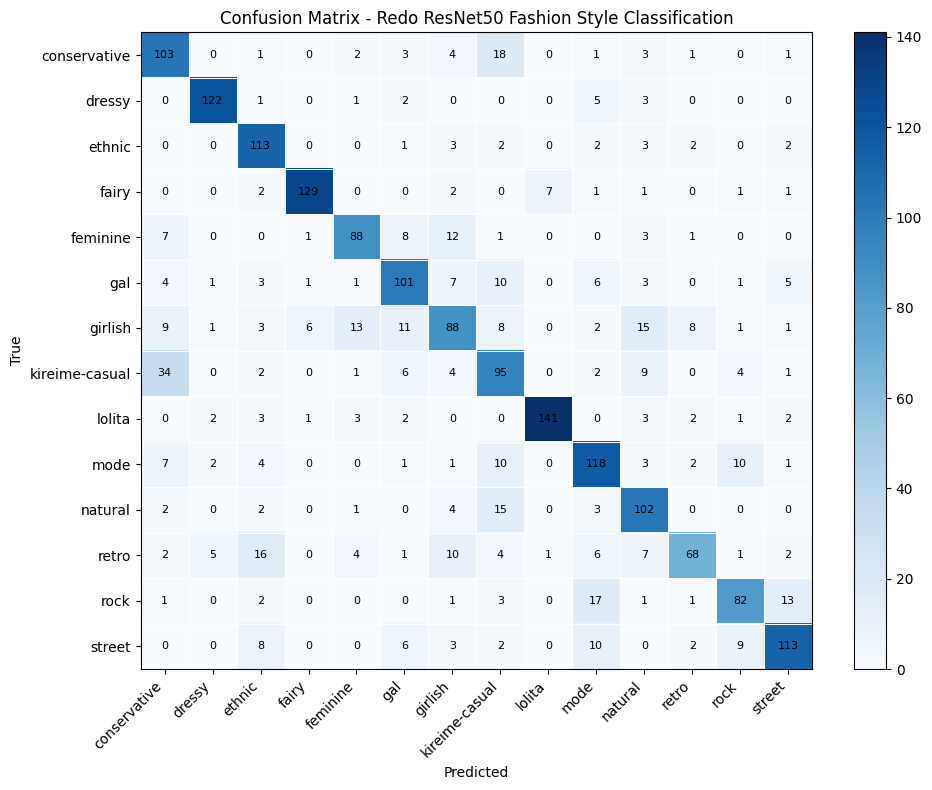

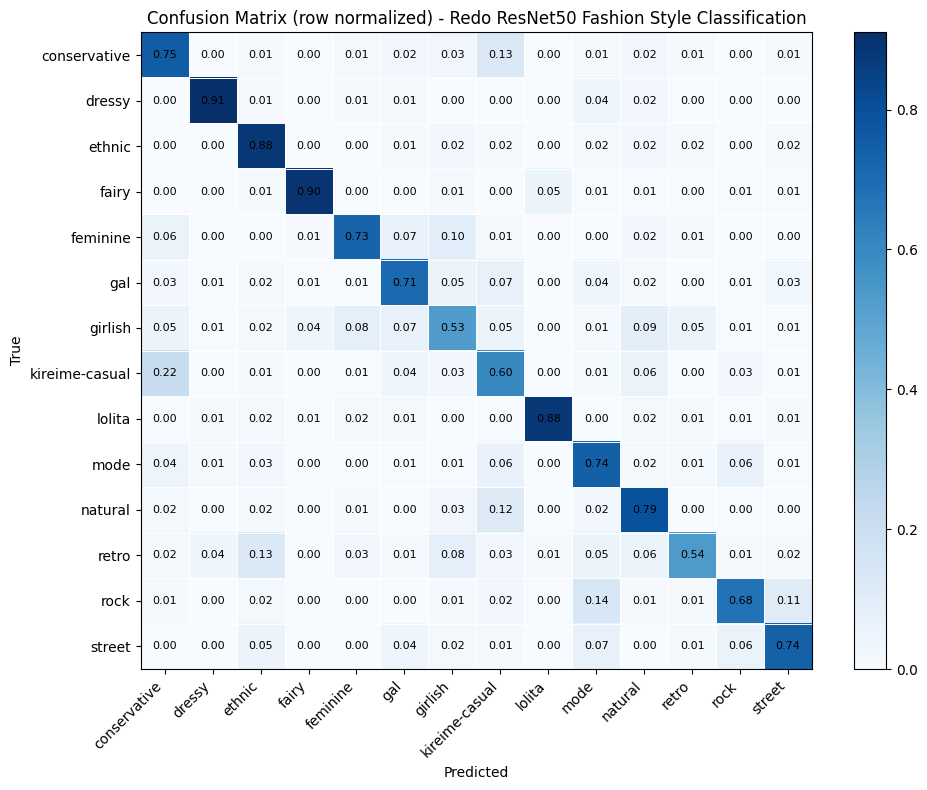

In [25]:
import numpy as np
import matplotlib.pyplot as plt

labels = list(cm_df.index)  # or your id_to_label order

def plot_heatmap_from_df(df, title="Confusion Matrix", normalize=None, annotate=True, out_path=None):
    """
    df: pandas.DataFrame confusion matrix (rows=true, cols=pred)
    normalize: None | "row" | "col"
    """
    data = df.values.astype(float)
    decimals = 0
    if normalize == "row":
        data = data / np.clip(data.sum(axis=1, keepdims=True), 1e-12, None)
        decimals = 2
    elif normalize == "col":
        data = data / np.clip(data.sum(axis=0, keepdims=True), 1e-12, None)
        decimals = 2

    C = data.shape[0]
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(data, aspect="auto", cmap="Blues")

    ax.set_xticks(range(C)); ax.set_yticks(range(C))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)

    # light grid lines (like seaborn)
    ax.set_xticks(np.arange(-.5, C, 1), minor=True)
    ax.set_yticks(np.arange(-.5, C, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.colorbar(im, ax=ax)

    if annotate:
        fmt = f"{{:.{decimals}f}}" if decimals else "{:d}"
        for i in range(C):
            for j in range(C):
                val = data[i, j]
                ax.text(j, i, fmt.format(val if decimals else int(round(val))),
                        ha="center", va="center", fontsize=8)

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# Usage:
plot_heatmap_from_df(cm_df, title="Confusion Matrix - Redo ResNet50 Fashion Style Classification", normalize=None, annotate=True)
plot_heatmap_from_df(cm_df, title="Confusion Matrix (row normalized) - Redo ResNet50 Fashion Style Classification", normalize="row", annotate=True)
